In [ ]:
!pip install EoN

In [ ]:
import pandas as pd
import plotly.graph_objs as go
import numpy as np
import EoN
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
airports_path = '/content/drive/MyDrive/OpenFlights/airports.dat'
routes_path = '/content/drive/MyDrive/OpenFlights/routes.dat'

In [ ]:
airports = pd.read_csv(airports_path, header=None)
airports.columns = ['Airport_ID', 'Name', 'City', 'Country', 'IATA', 'ICAO',
                    'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST',
                    'TZ_database_time_zone', 'Type', 'Source']

In [ ]:
routes = pd.read_csv(routes_path, header=None)
routes.columns = ['Airline', 'Airline_ID', 'Source_Airport', 'Source_Airport_ID',
                  'Destination_Airport', 'Destination_Airport_ID', 'Codeshare',
                  'Stops', 'Equipment']

In [ ]:
print("Sample Airports:")
print(airports.head())

Sample Airports:
   Airport_ID                                         Name          City  \
0           1                               Goroka Airport        Goroka   
1           2                               Madang Airport        Madang   
2           3                 Mount Hagen Kagamuga Airport   Mount Hagen   
3           4                               Nadzab Airport        Nadzab   
4           5  Port Moresby Jacksons International Airport  Port Moresby   

            Country IATA  ICAO  Latitude   Longitude  Altitude Timezone DST  \
0  Papua New Guinea  GKA  AYGA -6.081690  145.391998      5282       10   U   
1  Papua New Guinea  MAG  AYMD -5.207080  145.789001        20       10   U   
2  Papua New Guinea  HGU  AYMH -5.826790  144.296005      5388       10   U   
3  Papua New Guinea  LAE  AYNZ -6.569803  146.725977       239       10   U   
4  Papua New Guinea  POM  AYPY -9.443380  147.220001       146       10   U   

  TZ_database_time_zone     Type       Source  
0  

In [ ]:
print("\nSample Routes:")
print(routes.head())


Sample Routes:
  Airline Airline_ID Source_Airport Source_Airport_ID Destination_Airport  \
0      2B        410            AER              2965                 KZN   
1      2B        410            ASF              2966                 KZN   
2      2B        410            ASF              2966                 MRV   
3      2B        410            CEK              2968                 KZN   
4      2B        410            CEK              2968                 OVB   

  Destination_Airport_ID Codeshare  Stops Equipment  
0                   2990       NaN      0       CR2  
1                   2990       NaN      0       CR2  
2                   2962       NaN      0       CR2  
3                   2990       NaN      0       CR2  
4                   4078       NaN      0       CR2  


In [ ]:
# Build a dictionary mapping Airport ID -> Country
airport_id_to_country = {}

for index, row in airports.iterrows():
    airport_id = row['Airport_ID']
    country = row['Country']
    airport_id_to_country[airport_id] = country

print(f"Mapped {len(airport_id_to_country)} airports to their respective countries.")

Mapped 7698 airports to their respective countries.


In [ ]:
# Initialize directed graph
G_country = nx.DiGraph()

In [ ]:
# Build weighted edges
for index, row in routes.iterrows():
    try:
        source_id = int(row['Source_Airport_ID'])
        dest_id = int(row['Destination_Airport_ID'])
    except:
        continue

    if source_id not in airport_id_to_country or dest_id not in airport_id_to_country:
        continue

    source_country = airport_id_to_country[source_id]
    dest_country = airport_id_to_country[dest_id]

    if source_country != dest_country:
        if G_country.has_edge(source_country, dest_country):
            G_country[source_country][dest_country]['weight'] += 1
        else:
            G_country.add_edge(source_country, dest_country, weight=1)

print(f"Built directed weighted graph with {G_country.number_of_nodes()} countries and {G_country.number_of_edges()} weighted connections.")

Built directed weighted graph with 225 countries and 4558 weighted connections.


In [ ]:
# Step 1: Build country center coordinates
country_coords = {}

for country in airports['Country'].unique():
    subset = airports[airports['Country'] == country]
    if subset.empty:
        continue
    avg_lat = subset['Latitude'].mean()
    avg_lon = subset['Longitude'].mean()
    country_coords[country] = (avg_lat, avg_lon)

print(f"Calculated center coordinates for {len(country_coords)} countries.")

Calculated center coordinates for 237 countries.


In [ ]:
def h_index_centrality(G):
    h_index = {}
    for node in G.nodes():
        neighbor_degrees = [G.degree(neighbor) for neighbor in G.neighbors(node)]
        neighbor_degrees.sort(reverse=True)
        h = 0
        for i, d in enumerate(neighbor_degrees, start=1):
            if d >= i:
                h = i
            else:
                break
        h_index[node] = h
    return h_index

In [ ]:
out_degree_centrality = nx.out_degree_centrality(G_country)
betweenness_centrality = nx.betweenness_centrality(G_country)
closeness_centrality = nx.closeness_centrality(G_country)
eigenvector_centrality = nx.eigenvector_centrality(G_country)
h_index_centrality_dict = h_index_centrality(G_country)

print("Centrality scores computed.")

Centrality scores computed.


In [ ]:
def get_top_countries(centrality_dict, N=5):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:N]

# Leave non-zero countries
def get_bottom_countries(centrality_dict, N=5, epsilon=1e-6):
    # Exclude extremely small centrality values for better comparison visualization
    filtered = [(k, v) for k, v in centrality_dict.items() if v > epsilon]
    sorted_filtered = sorted(filtered, key=lambda x: x[1])

    if len(sorted_filtered) < N:
        print(f"Warning: Only {len(sorted_filtered)} countries found with centrality > {epsilon}")

    return sorted_filtered[:N]

In [ ]:
# Store centrality results here
centrality_categories = {}

# Function to get and store top/bottom countries
def store_centrality(metric_name, centrality_dict):
    centrality_categories[f"highest_{metric_name}"] = get_top_countries(centrality_dict)
    centrality_categories[f"lowest_{metric_name}"] = get_bottom_countries(centrality_dict)

In [ ]:
store_centrality("out_degree", out_degree_centrality)
store_centrality("betweenness", betweenness_centrality)
store_centrality("closeness", closeness_centrality)
store_centrality("eigenvector", eigenvector_centrality)
store_centrality("h_index", h_index_centrality_dict)

In [ ]:
def print_centrality_summary(metric_name, precision=4):
    print(f"\nCountries with High {metric_name.replace('_', ' ').title()} Centrality:")
    for country, score in centrality_categories[f"highest_{metric_name}"]:
        print(f"{country}: {score:.{precision}f}" if isinstance(score, float) else f"{country}: {score}")

    print(f"\nCountries with Low (Non-Zero) {metric_name.replace('_', ' ').title()} Centrality:")
    for country, score in centrality_categories[f"lowest_{metric_name}"]:
        print(f"{country}: {score:.{precision}f}" if isinstance(score, float) else f"{country}: {score}")

In [ ]:
print_centrality_summary("out_degree")
print_centrality_summary("betweenness")
print_centrality_summary("closeness")
print_centrality_summary("eigenvector")
print_centrality_summary("h_index", precision=0)


Countries with High Out Degree Centrality:
France: 0.5134
United Kingdom: 0.4420
Germany: 0.4330
United States: 0.4152
United Arab Emirates: 0.4062

Countries with Low (Non-Zero) Out Degree Centrality:
Gibraltar: 0.0045
Tuvalu: 0.0045
American Samoa: 0.0045
Falkland Islands: 0.0045
Niue: 0.0045

Countries with High Betweenness Centrality:
United States: 0.1744
France: 0.1312
United Kingdom: 0.0716
Australia: 0.0612
United Arab Emirates: 0.0586

Countries with Low (Non-Zero) Betweenness Centrality:
North Korea: 0.0000
Montenegro: 0.0000
Sao Tome and Principe: 0.0000
British Virgin Islands: 0.0000
Albania: 0.0000

Countries with High Closeness Centrality:
France: 0.6418
United States: 0.6205
Germany: 0.6188
United Kingdom: 0.6154
United Arab Emirates: 0.6087

Countries with Low (Non-Zero) Closeness Centrality:
Cocos (Keeling) Islands: 0.2481
Tuvalu: 0.2963
Micronesia: 0.2963
Wallis and Futuna: 0.2975
Saint Vincent and the Grenadines: 0.3128

Countries with High Eigenvector Centrality:
F

In [ ]:
def run_batch_sir_simulations(
    G,
    seed_countries,
    base_tau=0.02,
    gamma=0.05,
    max_steps=100,
    seed=None,
    deterministic=False,
    infection_threshold=0.5
):
    results = {}

    for country, _ in seed_countries:
        np.random.seed(seed)  # Ensures reproducibility for each country
        status = {node: 'S' for node in G.nodes()}
        status[country] = 'I'

        infected_nodes = set([country])
        recovered_nodes = set()

        time_steps = []
        infected_counts = []
        recovered_counts = []
        all_statuses = []

        for t in range(max_steps):
            new_infected = set()
            new_recovered = set()

            for node in infected_nodes:
                for neighbor in G.successors(node):
                    if status[neighbor] == 'S':
                        weight = G[node][neighbor]['weight']
                        transmission_prob = 1 - (1 - base_tau) ** weight

                        if deterministic:
                            if transmission_prob >= infection_threshold:
                                new_infected.add(neighbor)
                        else:
                            if np.random.rand() < transmission_prob:
                                new_infected.add(neighbor)

            for node in infected_nodes:
                if deterministic:
                    if gamma >= 1.0:
                        new_recovered.add(node)
                else:
                    if np.random.rand() < gamma:
                        new_recovered.add(node)

            for node in new_infected:
                status[node] = 'I'
            for node in new_recovered:
                status[node] = 'R'

            infected_nodes -= new_recovered
            infected_nodes |= new_infected
            recovered_nodes |= new_recovered

            all_statuses.append(status.copy())
            infected_counts.append(len(infected_nodes))
            recovered_counts.append(len(recovered_nodes))
            time_steps.append(t)

            if not infected_nodes:
                break

        results[country] = {
            "time_steps": time_steps,
            "infected_counts": infected_counts,
            "recovered_counts": recovered_counts,
            "final_size": len(recovered_nodes),
            "all_statuses": all_statuses
        }

    return results


In [ ]:
simulation_results = {}

for group_name, seed_countries in centrality_categories.items():
    print(f"Running simulations for: {group_name}...")
    results = run_batch_sir_simulations(
        G=G_country,
        seed_countries=seed_countries,
        base_tau=0.02,
        gamma=0.05,
        max_steps=300,
        seed=42
    )
    simulation_results[group_name] = results

Running simulations for: highest_out_degree...
Running simulations for: lowest_out_degree...
Running simulations for: highest_betweenness...
Running simulations for: lowest_betweenness...
Running simulations for: highest_closeness...
Running simulations for: lowest_closeness...
Running simulations for: highest_eigenvector...
Running simulations for: lowest_eigenvector...
Running simulations for: highest_h_index...
Running simulations for: lowest_h_index...


In [ ]:
def summarize_simulation_results(simulation_results):
    summary_data = []

    for group_name, country_results in simulation_results.items():
        for country, result in country_results.items():
            final_size = result['final_size']
            peak_infected = max(result['infected_counts']) if result['infected_counts'] else 0
            duration = len(result['time_steps'])

            summary_data.append({
                "Group": group_name,
                "Country": country,
                "FinalSize": final_size,
                "PeakInfected": peak_infected,
                "Duration": duration
            })

    return pd.DataFrame(summary_data)


In [ ]:
summary_df = summarize_simulation_results(simulation_results)

In [ ]:
def plot_average_infection_curves(simulation_results, metric_keyword):
    plt.figure(figsize=(10, 6))

    for group_name, country_results in simulation_results.items():
        if metric_keyword not in group_name:
            continue

        max_len = max(len(r['infected_counts']) for r in country_results.values())
        all_curves = []

        for r in country_results.values():
            curve = r['infected_counts']
            padded = curve + [0] * (max_len - len(curve))
            all_curves.append(padded)

        avg_curve = np.mean(all_curves, axis=0)
        label = group_name.replace("highest_", "High ").replace("lowest_", "Low ").replace("_", " ").title()
        plt.plot(avg_curve, label=label)

    plt.xlabel("Time Step")
    plt.ylabel("Average Infected Nodes")
    plt.title(f"Infection Curves for {metric_keyword.replace('_', ' ').title()} Centrality")
    plt.legend()
    plt.grid(True)
    plt.show()

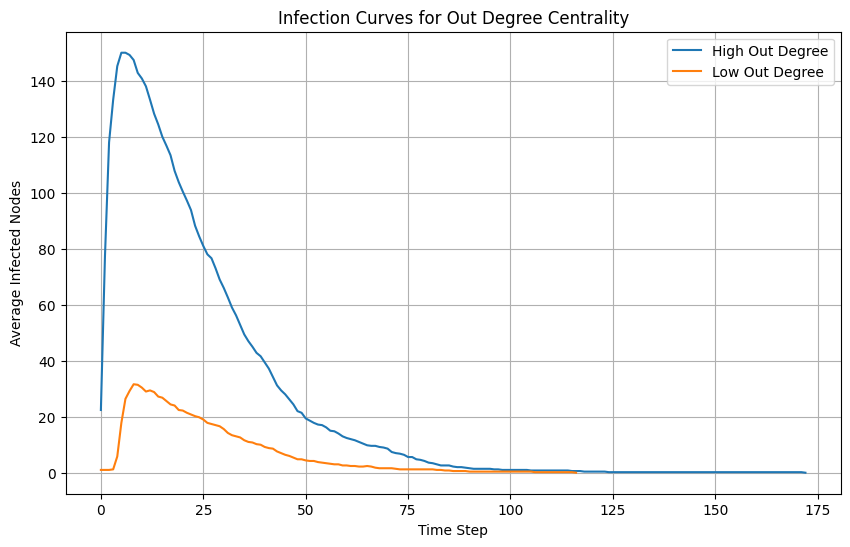

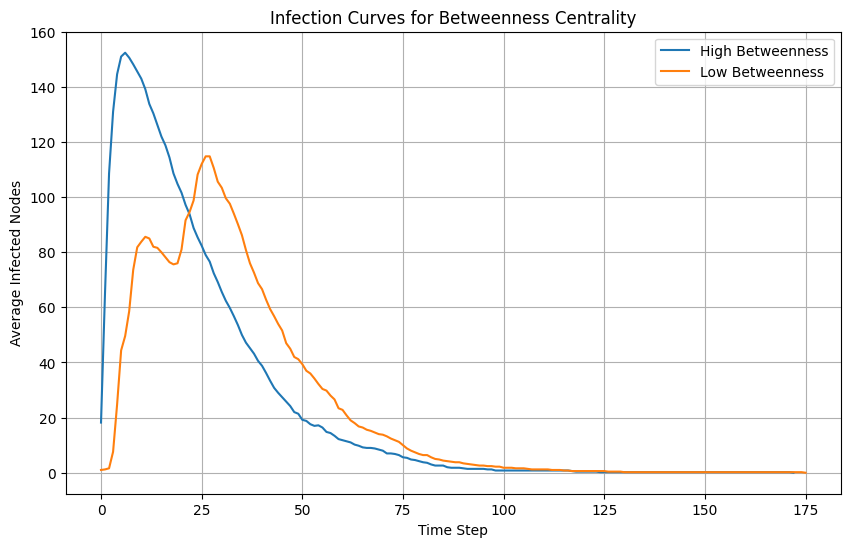

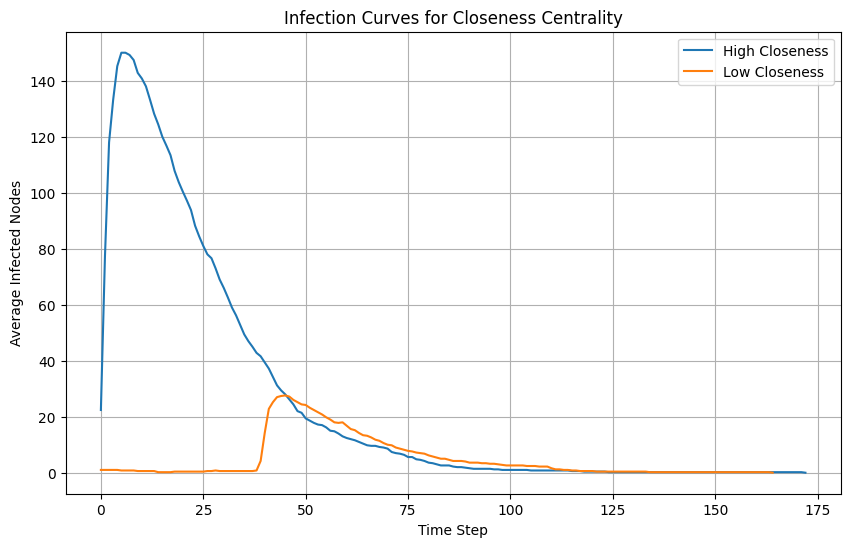

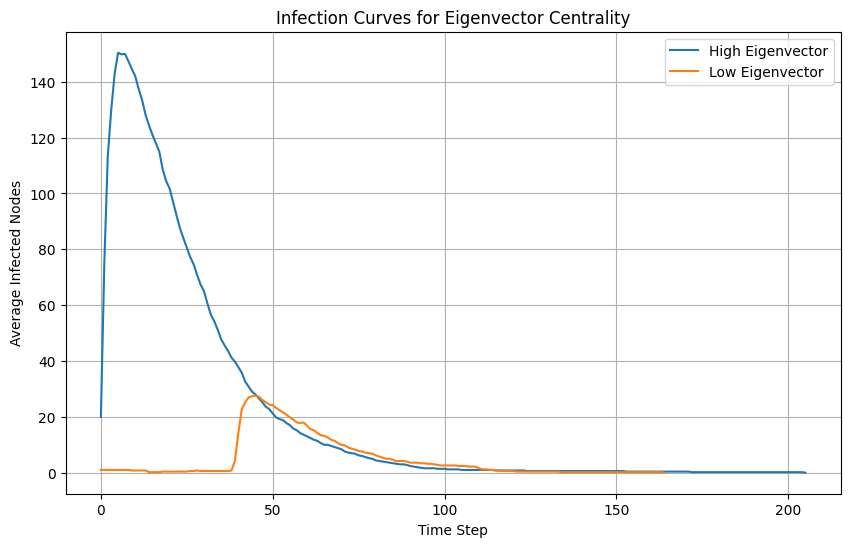

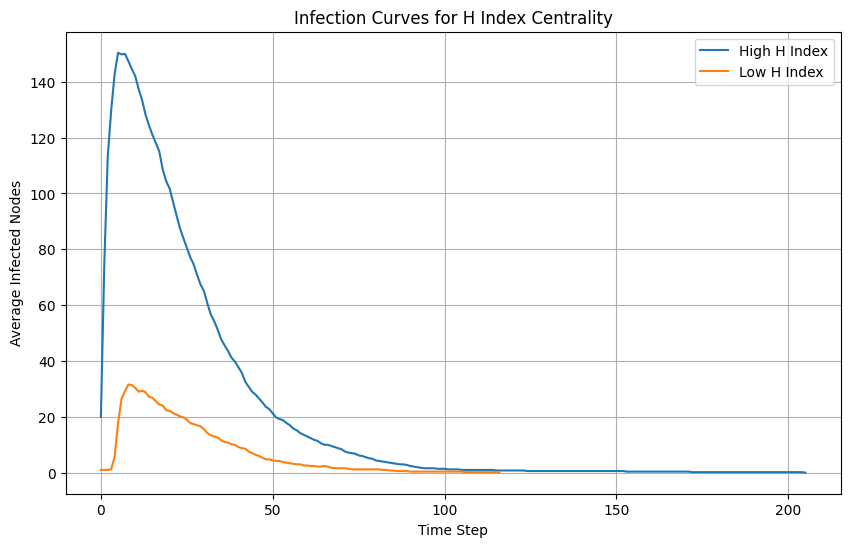

In [ ]:
plot_average_infection_curves(simulation_results, "out_degree")
plot_average_infection_curves(simulation_results, "betweenness")
plot_average_infection_curves(simulation_results, "closeness")
plot_average_infection_curves(simulation_results, "eigenvector")
plot_average_infection_curves(simulation_results, "h_index")

In [ ]:
def plot_country_infection_curves(sim_results, group_name):
    if group_name not in sim_results:
        print(f"Group '{group_name}' not found.")
        return

    plt.figure(figsize=(10, 6))
    for country, result in sim_results[group_name].items():
        infected = result['infected_counts']
        plt.plot(infected, label=country)

    title = group_name.replace("highest_", "High ").replace("lowest_", "Low ").replace("_", " ").title()
    plt.title(f"Infection Curves: {title}")
    plt.xlabel("Time Step")
    plt.ylabel("Number of Infected Countries")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

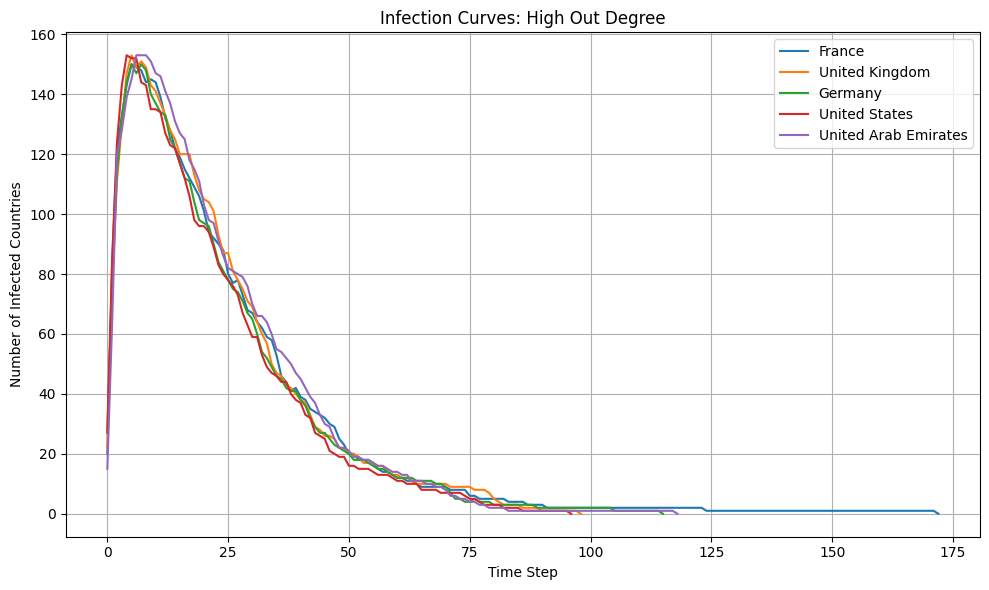

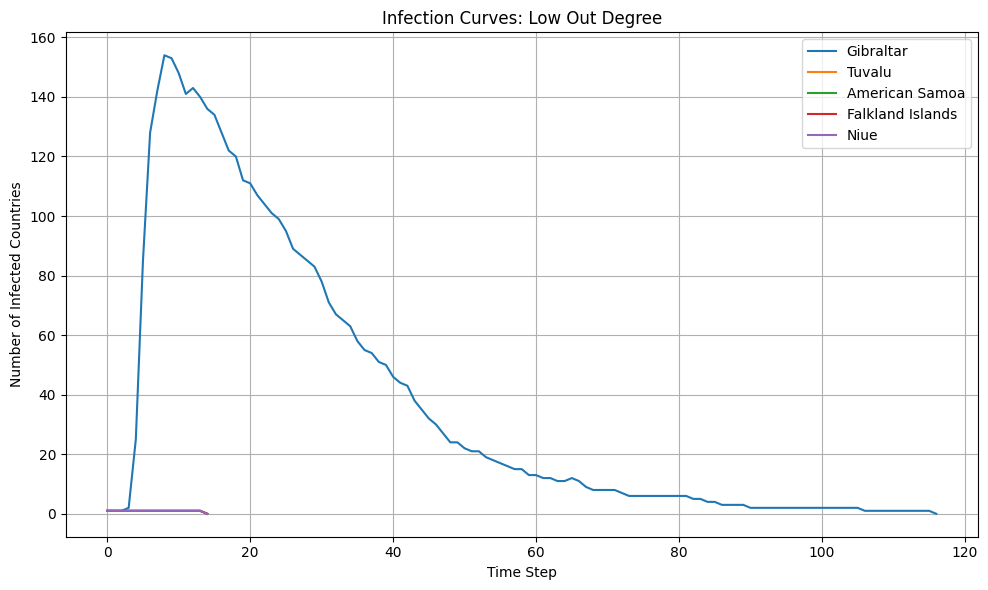

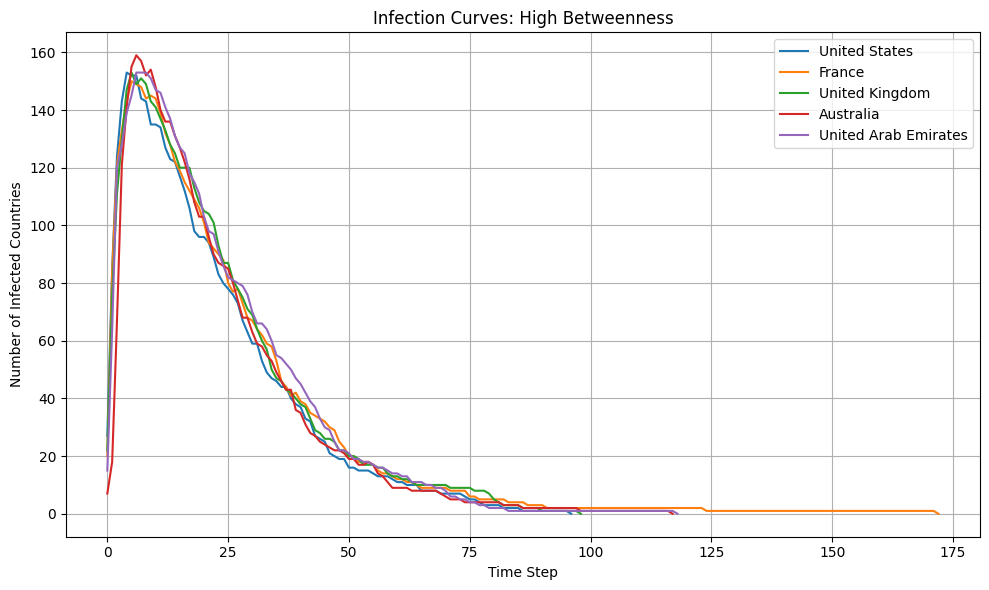

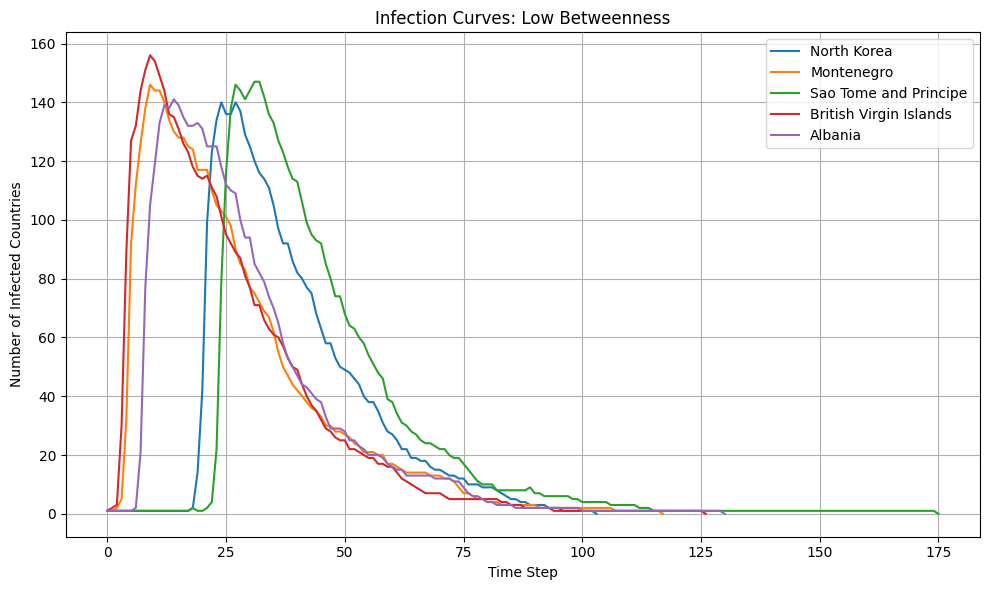

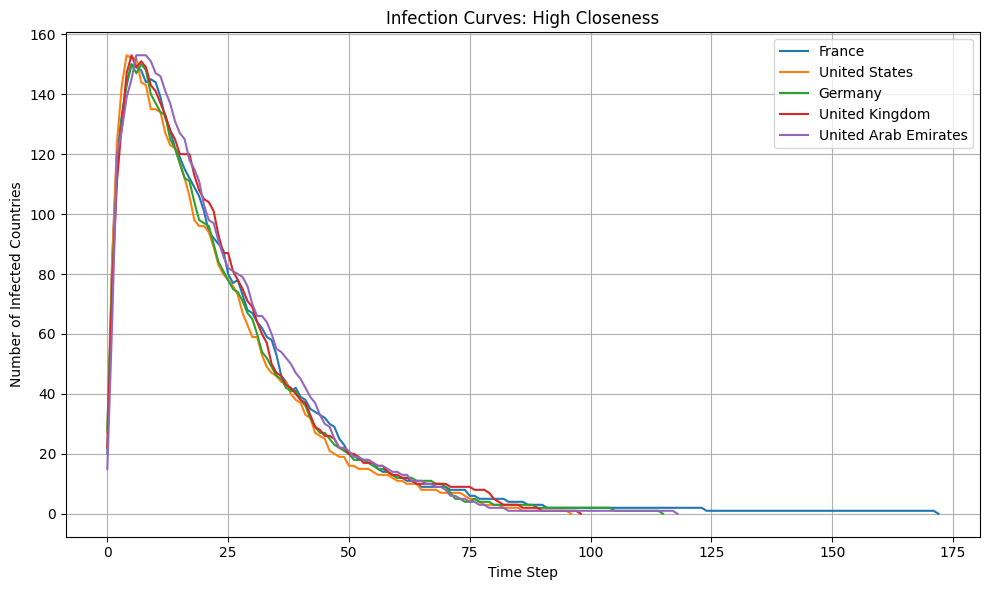

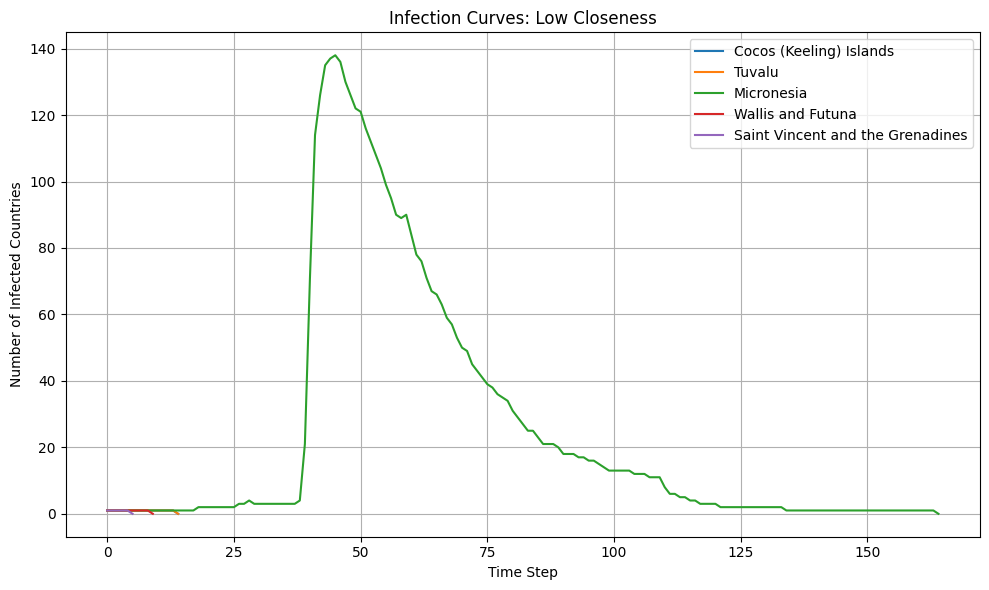

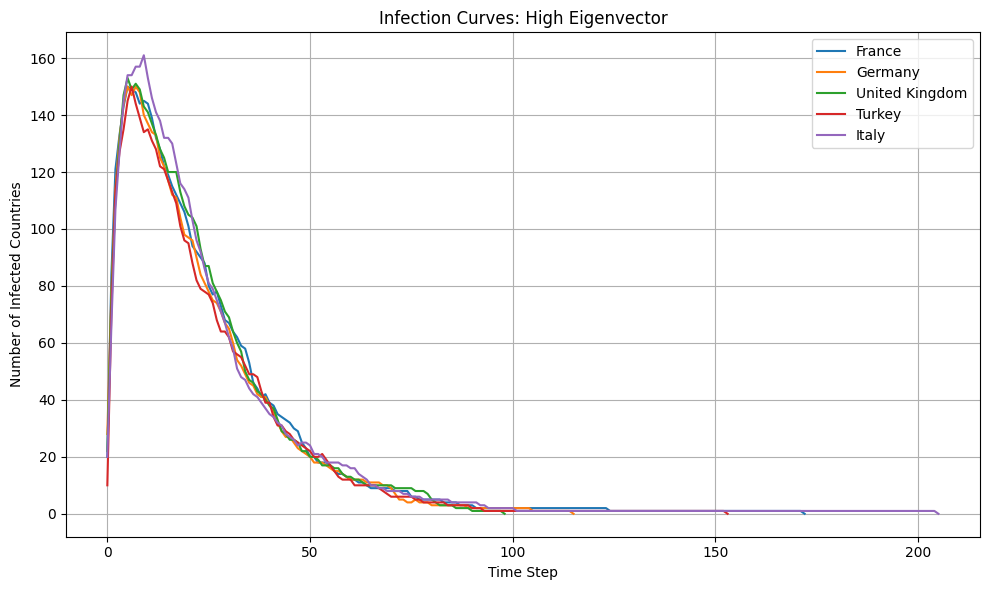

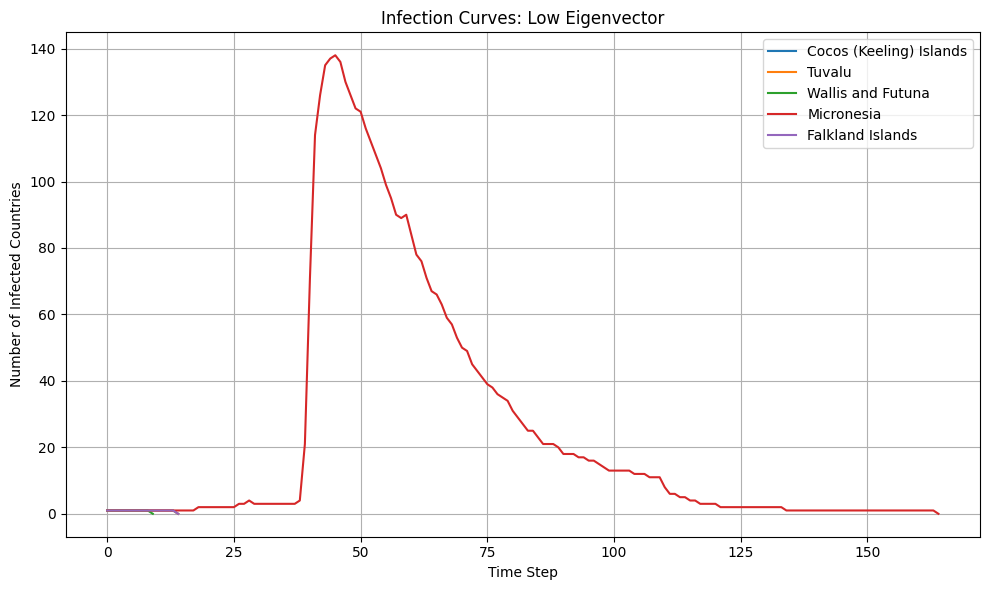

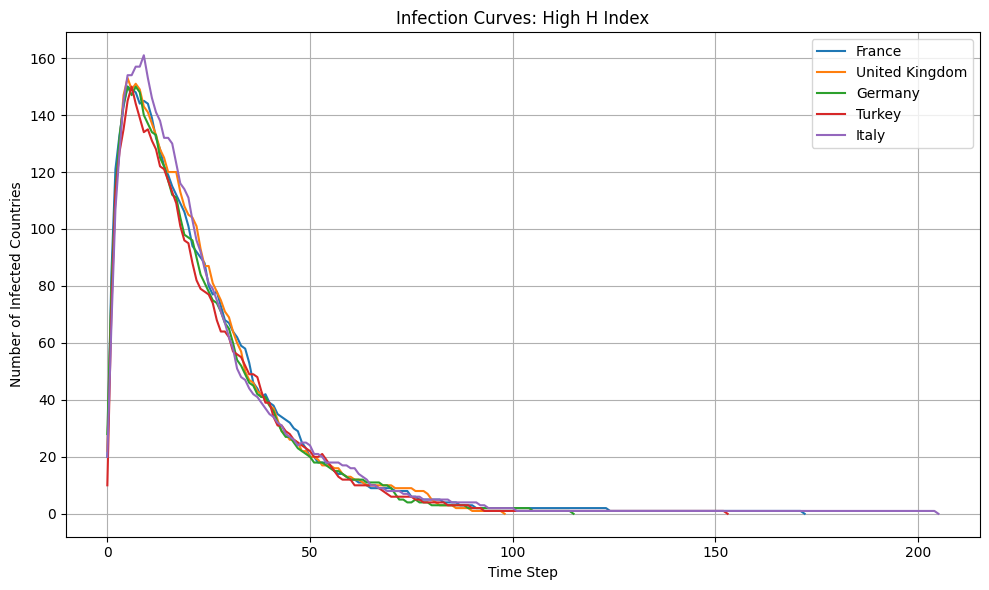

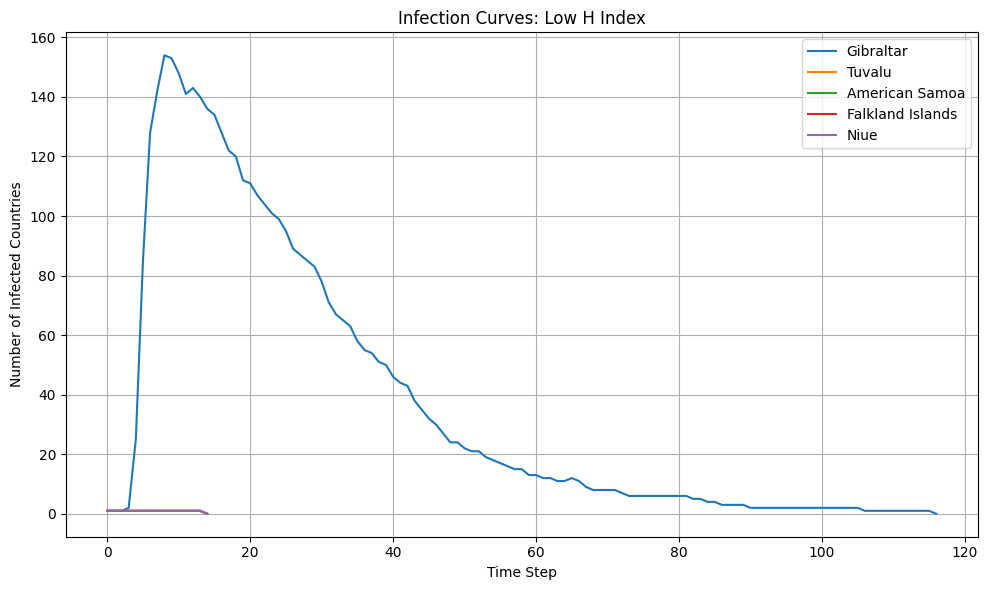

In [ ]:
for group in centrality_categories.keys():
    plot_country_infection_curves(simulation_results, group)

In [ ]:
def find_peak_info(infected_counts):
    if not infected_counts:
        return 0, 0
    peak_infected = max(infected_counts)
    # Find the first time step where the peak was reached
    peak_time = infected_counts.index(peak_infected) if peak_infected > 0 else 0
    return peak_time, peak_infected

def calculate_average_peak_metrics(simulation_results, metric_keyword):
    high_group_name = f"highest_{metric_keyword}"
    low_group_name = f"lowest_{metric_keyword}"

    high_peak_times = []
    high_peak_sizes = []
    low_peak_times = []
    low_peak_sizes = []

    if high_group_name in simulation_results:
        for country, result in simulation_results[high_group_name].items():
            peak_time, peak_size = find_peak_info(result['infected_counts'])
            high_peak_times.append(peak_time)
            high_peak_sizes.append(peak_size)

    if low_group_name in simulation_results:
        for country, result in simulation_results[low_group_name].items():
            peak_time, peak_size = find_peak_info(result['infected_counts'])
            low_peak_times.append(peak_time)
            low_peak_sizes.append(peak_size)

    avg_high_peak_time = np.mean(high_peak_times) if high_peak_times else 0
    avg_high_peak_size = np.mean(high_peak_sizes) if high_peak_sizes else 0
    avg_low_peak_time = np.mean(low_peak_times) if low_peak_times else 0
    avg_low_peak_size = np.mean(low_peak_sizes) if low_peak_sizes else 0

    return (avg_high_peak_time, avg_high_peak_size,
            avg_low_peak_time, avg_low_peak_size)

print("Centrality Metric | Avg Peak Time (High) | Avg Peak Size (High) | Avg Peak Time (Low) | Avg Peak Size (Low) | Peak Time Diff | Peak Size Diff")
print("------------------|----------------------|----------------------|---------------------|---------------------|----------------|---------------")

metrics_to_compare = ["betweenness", "closeness", "eigenvector", "h_index"]

for metric in metrics_to_compare:
    avg_high_time, avg_high_size, avg_low_time, avg_low_size = calculate_average_peak_metrics(simulation_results, metric)

    time_diff = avg_low_time - avg_high_time
    size_diff = avg_high_size - avg_low_size

    print(f"{metric.title():<17} | {avg_high_time:<20.2f} | {avg_high_size:<20.2f} | {avg_low_time:<19.2f} | {avg_low_size:<19.2f} | {time_diff:<14.2f} | {size_diff:<13.2f}")

Centrality Metric | Avg Peak Time (High) | Avg Peak Size (High) | Avg Peak Time (Low) | Avg Peak Size (Low) | Peak Time Diff | Peak Size Diff
------------------|----------------------|----------------------|---------------------|---------------------|----------------|---------------
Betweenness       | 5.20                 | 153.60               | 17.40               | 146.00              | 12.20          | 7.60         
Closeness         | 5.00                 | 151.80               | 9.00                | 28.40               | 4.00           | 123.40       
Eigenvector       | 6.00                 | 152.80               | 9.00                | 28.40               | 3.00           | 124.40       
H_Index           | 6.00                 | 152.80               | 1.60                | 31.60               | -4.40          | 121.20       


In [ ]:
!pip install basemap


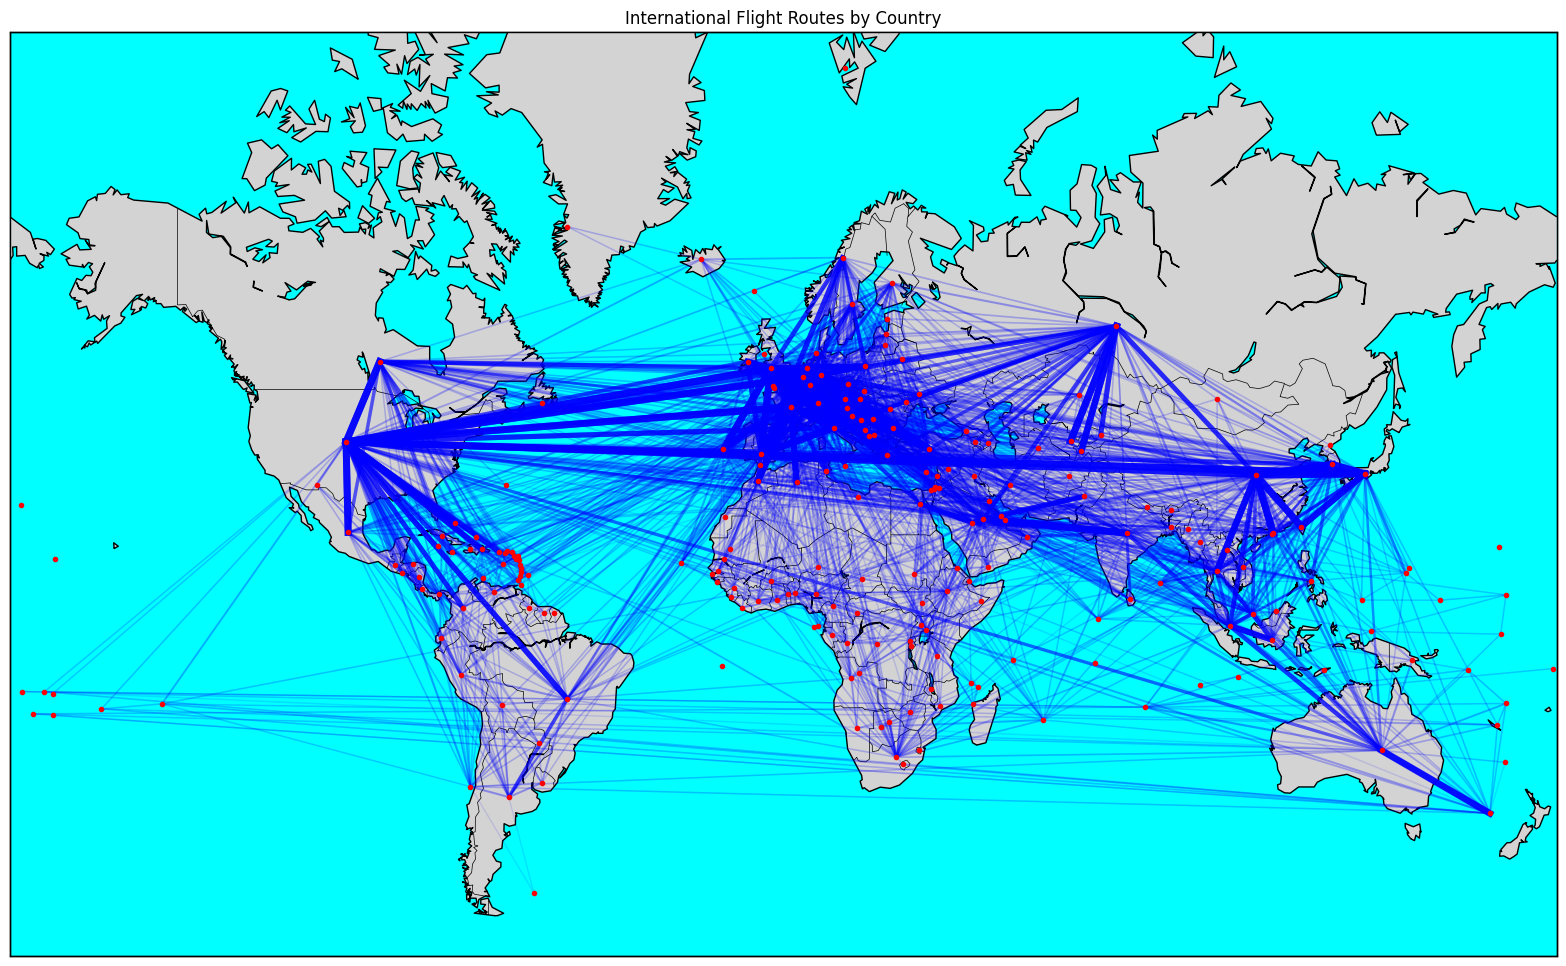

In [ ]:
from mpl_toolkits.basemap import Basemap

# Set up the world map using Basemap
plt.figure(figsize=(20, 12))
m = Basemap(projection='merc', llcrnrlat=-60, urcrnrlat=80,
            llcrnrlon=-180, urcrnrlon=180, lat_ts=20, resolution='c')

m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray', lake_color='aqua')
m.drawmapboundary(fill_color='aqua')

# Draw graph edges
for source, target, data in G_country.edges(data=True):
    if source not in country_coords or target not in country_coords:
        continue

    lat1, lon1 = country_coords[source]
    lat2, lon2 = country_coords[target]
    x1, y1 = m(lon1, lat1)
    x2, y2 = m(lon2, lat2)

    # Use weight to affect transparency and line width
    weight = data['weight']
    alpha = min(0.8, 0.1 + weight / 100)  # Adjust for better visibility
    lw = min(5, 1 + weight / 20)

    plt.plot([x1, x2], [y1, y2], color='blue', alpha=alpha, linewidth=lw)

# Draw nodes
for country, (lat, lon) in country_coords.items():
    x, y = m(lon, lat)
    plt.plot(x, y, 'ro', markersize=3)

plt.title('International Flight Routes by Country')
plt.show()